In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

daily_returns = pd.read_csv("../data/processed/daily_returns.csv", index_col=0, parse_dates=True)

tickers = daily_returns.columns.tolist()
n_assets = len(tickers)

daily_returns.head()

,SPY,QQQ,IWM,TLT,GLD,VNQ,EFA
Date,,,,,,,
2015-01-05,-0.018060,-0.014676,-0.013369,0.015708,0.015077,0.005473,-0.023605
2015-01-06,-0.009419,-0.013415,-0.017300,0.018017,0.011399,0.009919,-0.011327
2015-01-07,0.012461,0.012897,0.012315,-0.001975,-0.005891,0.015331,0.011115
2015-01-08,0.017745,0.019149,0.016962,-0.013243,-0.004209,0.003775,0.013530
2015-01-09,-0.008014,-0.006586,-0.009603,0.010953,0.011385,0.000470,-0.004839


In [2]:
trading_days = 252
risk_free_rate = 0.02

def portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate=0.02):
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    return portfolio_return, portfolio_volatility, sharpe_ratio

def minimum_variance_weights(returns_window):
    mean_returns = returns_window.mean() * trading_days
    cov_matrix = returns_window.cov() * trading_days
    
    n_assets = returns_window.shape[1]
    initial_weights = np.array([1 / n_assets] * n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
    
    def portfolio_volatility(weights):
        return portfolio_performance(weights, mean_returns, cov_matrix)[1]
    
    result = minimize(
        portfolio_volatility,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

def maximum_sharpe_weights(returns_window):
    mean_returns = returns_window.mean() * trading_days
    cov_matrix = returns_window.cov() * trading_days
    
    n_assets = returns_window.shape[1]
    initial_weights = np.array([1 / n_assets] * n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
    
    def negative_sharpe(weights):
        return -portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)[2]
    
    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

def risk_contribution(weights, cov_matrix):
    portfolio_var = np.dot(weights.T, np.dot(cov_matrix, weights))
    marginal_contrib = np.dot(cov_matrix, weights)
    risk_contrib = weights * marginal_contrib / portfolio_var
    return risk_contrib

def risk_parity_weights(returns_window):
    cov_matrix = returns_window.cov() * trading_days
    
    n_assets = returns_window.shape[1]
    initial_weights = np.array([1 / n_assets] * n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
    
    def risk_parity_objective(weights):
        rc = risk_contribution(weights, cov_matrix)
        target_rc = np.array([1 / n_assets] * n_assets)
        return np.sum((rc - target_rc) ** 2)
    
    result = minimize(
        risk_parity_objective,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

In [3]:
def rolling_backtest(daily_returns, lookback_window=252, rebalance_window=21):
    strategy_returns = {
        "Equal Weight": [],
        "Minimum Variance": [],
        "Maximum Sharpe": [],
        "Risk Parity": [],
        "SPY Benchmark": []
    }
    
    dates = []
    weights_history = {
        "Equal Weight": [],
        "Minimum Variance": [],
        "Maximum Sharpe": [],
        "Risk Parity": []
    }
    
    for start in range(lookback_window, len(daily_returns) - rebalance_window, rebalance_window):
        train_window = daily_returns.iloc[start - lookback_window:start]
        test_window = daily_returns.iloc[start:start + rebalance_window]
        
        equal_w = np.array([1 / n_assets] * n_assets)
        min_var_w = minimum_variance_weights(train_window)
        max_sharpe_w = maximum_sharpe_weights(train_window)
        risk_parity_w = risk_parity_weights(train_window)
        
        weights_dict = {
            "Equal Weight": equal_w,
            "Minimum Variance": min_var_w,
            "Maximum Sharpe": max_sharpe_w,
            "Risk Parity": risk_parity_w
        }
        
        for strategy, weights in weights_dict.items():
            returns = test_window.dot(weights)
            strategy_returns[strategy].extend(returns.tolist())
            weights_history[strategy].append(weights)
        
        strategy_returns["SPY Benchmark"].extend(test_window["SPY"].tolist())
        dates.extend(test_window.index.tolist())
    
    backtest_returns = pd.DataFrame(strategy_returns, index=dates)
    
    return backtest_returns, weights_history

In [4]:
backtest_returns, weights_history = rolling_backtest(
    daily_returns,
    lookback_window=252,
    rebalance_window=21
)

backtest_returns.head()

,Equal Weight,Minimum Variance,Maximum Sharpe,Risk Parity,SPY Benchmark
2016-01-05,0.002666,-0.000240,-0.001736,0.001293,0.001691
2016-01-06,-0.004106,0.002448,-0.009611,0.000425,-0.012614
2016-01-07,-0.015195,-0.006126,-0.031331,-0.009636,-0.023992
2016-01-08,-0.008812,-0.004806,-0.008110,-0.006158,-0.010977
2016-01-11,-0.001462,-0.006157,0.003078,-0.003878,0.000990


In [5]:
backtest_returns.shape

(2499, 5)

In [6]:
backtest_returns.to_csv("../data/processed/backtest_returns.csv")

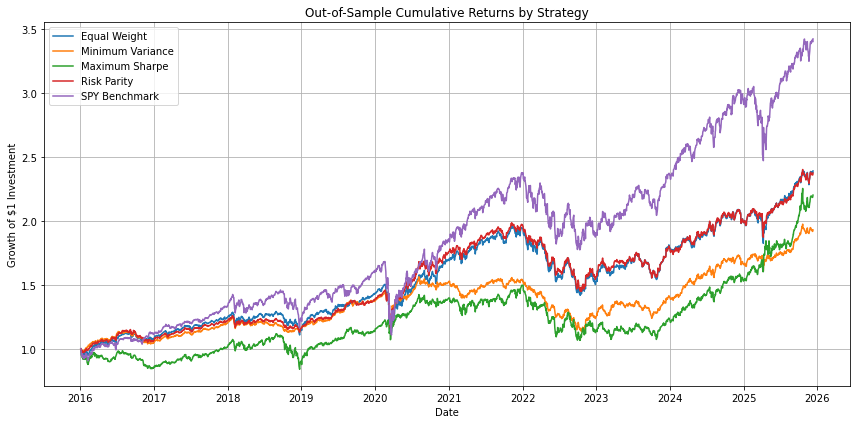

In [7]:
backtest_cumulative_returns = (1 + backtest_returns).cumprod()

plt.figure(figsize=(12, 6))

x = backtest_cumulative_returns.index.to_numpy()

for column in backtest_cumulative_returns.columns:
    y = backtest_cumulative_returns[column].to_numpy()
    plt.plot(x, y, label=column)

plt.title("Out-of-Sample Cumulative Returns by Strategy")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../figures/backtest_cumulative_returns.png", dpi=300)
plt.show()

In [8]:
backtest_performance = pd.DataFrame({
    "Annualized Return": backtest_returns.mean() * 252,
    "Annualized Volatility": backtest_returns.std() * np.sqrt(252),
    "Sharpe Ratio": (backtest_returns.mean() * 252 - risk_free_rate) / (backtest_returns.std() * np.sqrt(252))
})

backtest_performance.T

,Equal Weight,Minimum Variance,Maximum Sharpe,Risk Parity,SPY Benchmark
Annualized Return,0.097016,0.071141,0.091178,0.093681,0.140472
Annualized Volatility,0.134932,0.098525,0.152204,0.113890,0.181049
Sharpe Ratio,0.570779,0.519069,0.467649,0.646951,0.665409


In [9]:
backtest_performance.T.to_csv("../data/processed/backtest_performance.csv")

## Backtest Results Interpretation

The rolling-window backtest shows that the SPY benchmark achieved the highest annualized return and Sharpe ratio over the out-of-sample period. However, this came with the highest annualized volatility among all strategies. Among the portfolio construction methods, the risk parity strategy delivered the strongest risk-adjusted performance, with a Sharpe ratio close to the SPY benchmark but substantially lower volatility.

The maximum Sharpe strategy performed well in the static full-sample optimization, but its rolling-window backtest performance was weaker. This suggests that mean-variance optimization based on historical expected returns can be sensitive to estimation error and may not generalize well out of sample. The minimum variance strategy successfully reduced portfolio volatility, but at the cost of lower returns.

Overall, the backtest highlights the trade-off between return maximization and risk control. For a risk management-oriented project, the risk parity and minimum variance results are especially important because they demonstrate how portfolio construction methods can reduce volatility and improve downside risk characteristics.